In [1]:
# ============================================================
# CELL 1 - Load Test Data & Models
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

target = "co2"
features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy", "gdp_per_capita", "energy_per_capita"
]

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print("Test samples:", len(y_test))
print("Models evaluated:", len(models))

MODEL EVALUATION
Test samples: 273
Models evaluated: 3


FINAL MODEL COMPARISON


,Model,MAE,RMSE,R²
2,Gradient Boosting,22.5743,68.9022,0.9973
1,Random Forest,18.4689,85.7052,0.9959
0,Linear Regression,76.7764,135.3426,0.9898


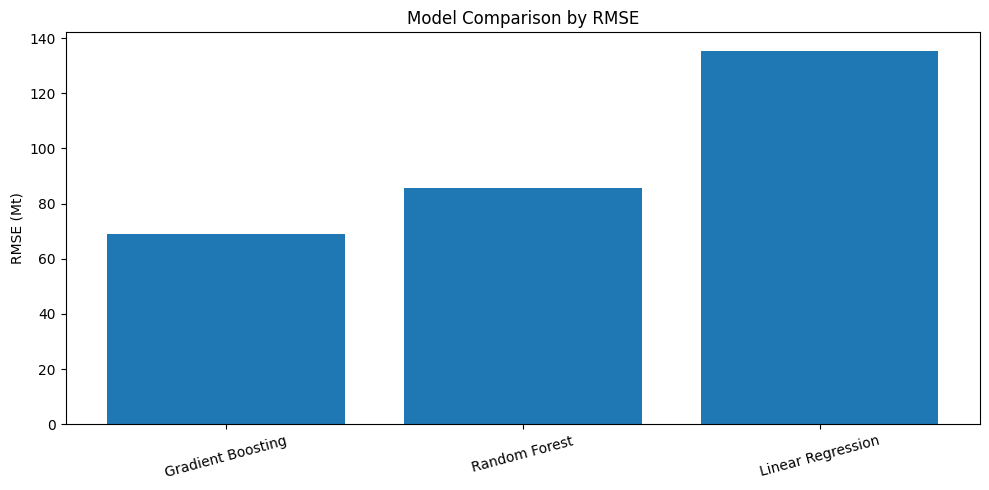

In [2]:
# ============================================================
# CELL 2 - Final Model Comparison
# ============================================================

results = []

for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"]).sort_values("RMSE")

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
display(results.round(4))

plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE (Mt)")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

BEST MODEL PERFORMANCE
Best model: Gradient Boosting
MAE: 22.5743
RMSE: 68.9022
R²: 0.9973


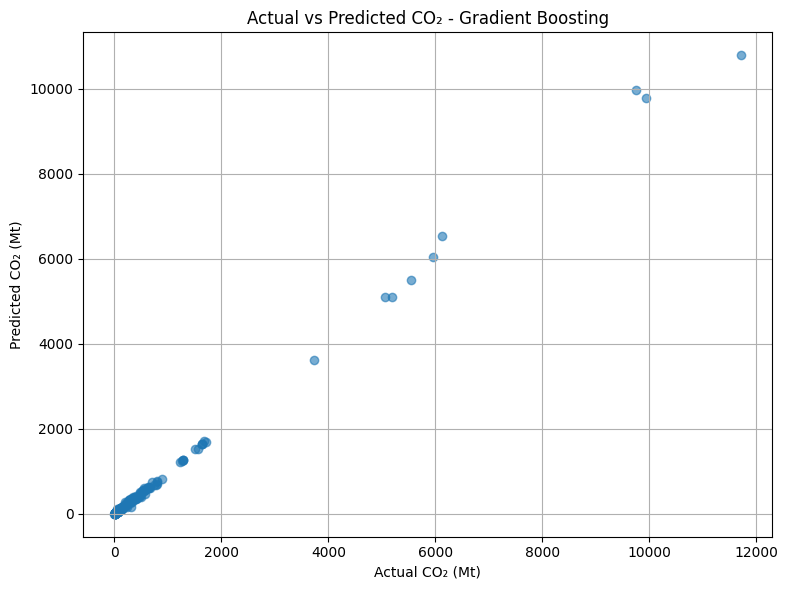

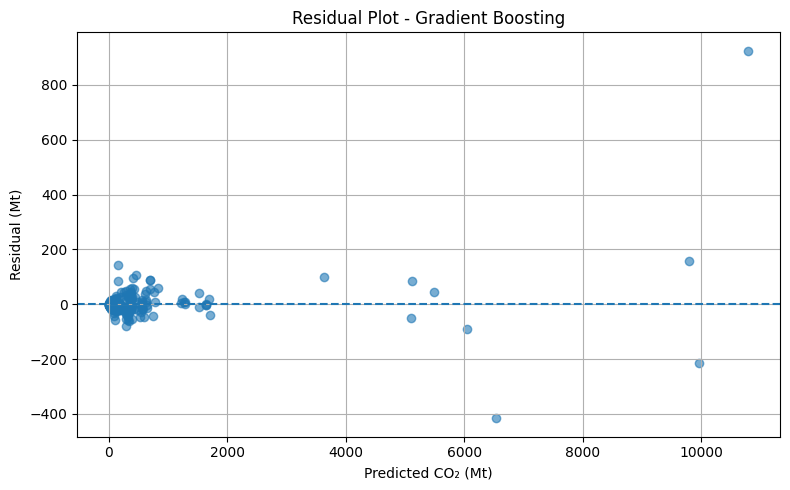

In [3]:
# ============================================================
# CELL 3 - Actual vs Predicted & Residuals
# ============================================================

best_model_name = results.iloc[0]["Model"]
best_pred = predictions[best_model_name]
residuals = y_test.values - best_pred

print("=" * 60)
print("BEST MODEL PERFORMANCE")
print("=" * 60)
print("Best model:", best_model_name)
print("MAE:", round(mean_absolute_error(y_test, best_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, best_pred)), 4))
print("R²:", round(r2_score(y_test, best_pred), 4))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xlabel("Actual CO₂ (Mt)")
plt.ylabel("Predicted CO₂ (Mt)")
plt.title(f"Actual vs Predicted CO₂ - {best_model_name}")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted CO₂ (Mt)")
plt.ylabel("Residual (Mt)")
plt.title(f"Residual Plot - {best_model_name}")
plt.grid(True)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE


,Feature,Importance
3,primary_energy_consumption_energy,0.921852
1,population_co2,0.061077
2,gdp_co2,0.007295
4,fossil_share_energy,0.002165
6,renewables_electricity,0.001293
12,energy_per_capita,0.001210
11,gdp_per_capita,0.001171
5,renewables_share_energy,0.001046
7,renewables_share_elec,0.000921
9,wind_share_energy,0.000803


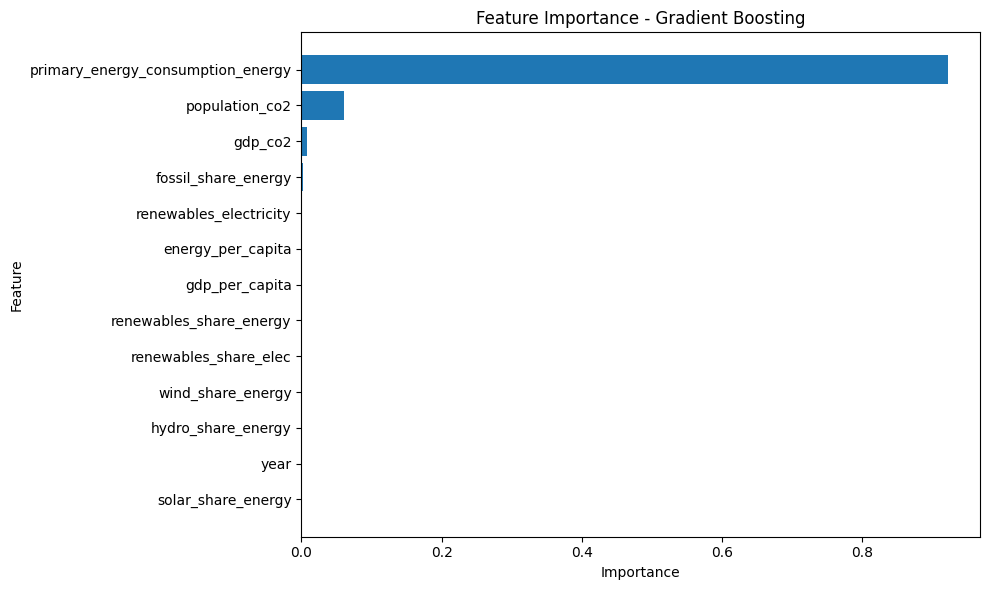

In [4]:
# ============================================================
# CELL 4 - Feature Importance
# ============================================================

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

if best_model_name == "Random Forest":
    importance = models["Random Forest"].feature_importances_
elif best_model_name == "Gradient Boosting":
    importance = models["Gradient Boosting"].feature_importances_
else:
    importance = np.abs(models["Linear Regression"].coef_)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"][::-1], feature_importance["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 5 - Save Evaluation Results
# ============================================================

EVAL_PATH = "../outputs/model_evaluation.csv"
IMPORTANCE_PATH = "../outputs/feature_importance.csv"

import os
os.makedirs("../outputs", exist_ok=True)

results.to_csv(EVAL_PATH, index=False)
feature_importance.to_csv(IMPORTANCE_PATH, index=False)

print("=" * 60)
print("EVALUATION RESULTS SAVED")
print("=" * 60)
print("Model evaluation:", EVAL_PATH)
print("Feature importance:", IMPORTANCE_PATH)

EVALUATION RESULTS SAVED
Model evaluation: ../outputs/model_evaluation.csv
Feature importance: ../outputs/feature_importance.csv
